In [1]:
# Imports and configuration
import os
import json
import random
from collections import defaultdict

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage
from scipy.signal import fftconvolve
from scipy.special import j1
import time

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required but was not found.")

DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# Paths
DATA_ROOT = "."
TRAIN_JSON = os.path.join(DATA_ROOT, "train", "_annotations.coco.json")
MODEL_PATH = os.path.join("models", "defect_detector_stage2_litho_finetuned.pth")

# Inference settings
CONFIDENCE_THRESHOLD = 0.5

print("Configuration loaded!")

Using device: cuda
Configuration loaded!


In [2]:
# Copy augmentation functions from training.ipynb

def inject_bright_particles(img_array, existing_boxes=None, num_particles=None):
    """Inject bright particles with moderate soft edges into image."""
    h, w = img_array.shape[:2]
    img_out = img_array.copy().astype(float)
    
    if num_particles is None:
        num_particles = random.randint(0, 2)
    
    new_boxes = []
    
    for _ in range(num_particles):
        # Large particle: 10-50% of image size
        min_diameter = int(min(h, w) * 0.10)
        max_diameter = int(min(h, w) * 0.50)
        diameter = random.randint(min_diameter, max_diameter)
        radius = diameter // 2
        
        margin = radius + 5
        cx = random.randint(margin, w - margin)
        cy = random.randint(margin, h - margin)
        
        peak_intensity = random.randint(200, 230)  # Toned down from 250-255
        
        y_coords, x_coords = np.ogrid[:h, :w]
        dist_sq = (x_coords - cx) ** 2 + (y_coords - cy) ** 2
        dist = np.sqrt(dist_sq)
        
        # Moderate soft edge (~30% of radius for softer transition)
        edge_width = max(5, radius * 0.3)
        particle = np.zeros_like(dist)
        
        # Inside the core: full intensity
        particle[dist <= radius - edge_width] = 1.0
        
        # Gradual soft edge transition (smoother falloff)
        edge_mask = (dist > radius - edge_width) & (dist <= radius + edge_width * 0.5)
        edge_dist = dist[edge_mask] - (radius - edge_width)
        edge_total = edge_width * 1.5
        particle[edge_mask] = 1.0 - (edge_dist / edge_total) ** 1.5  # Smoother curve
        
        particle = np.clip(particle, 0, 1) * peak_intensity
        img_out = np.maximum(img_out, particle)
        
        # Bounding box based on the hard circle radius
        x1 = max(0, int(cx - radius))
        y1 = max(0, int(cy - radius))
        x2 = min(w - 1, int(cx + radius))
        y2 = min(h - 1, int(cy + radius))
        new_boxes.append([x1, y1, x2, y2])
    
    img_out = np.clip(img_out, 0, 255).astype(np.uint8)
    return img_out, new_boxes


def convert_to_sem_style(img):
    """Apply SEM-style conversion."""
    img_gray = img.convert("L")
    img_array = np.array(img_gray).astype(float) / 255.0
    img_remapped = img_array * (-67 / 255.0) + (124 / 255.0)
    img_blur = ndimage.gaussian_filter(img_remapped, sigma=0.05)
    noise = np.random.normal(0, 0.015, img_blur.shape)
    img_noisy = img_blur + noise
    img_noisy = np.clip(img_noisy, 0.0, 1.0)
    
    grain_size = 2
    grain = np.random.normal(0, 0.01, (img_noisy.shape[0] // grain_size, img_noisy.shape[1] // grain_size))
    grain_upscaled = ndimage.zoom(grain, grain_size, order=1)
    if grain_upscaled.shape != img_noisy.shape:
        grain_upscaled = grain_upscaled[: img_noisy.shape[0], : img_noisy.shape[1]]
    img_grain = img_noisy + grain_upscaled
    img_grain = np.clip(img_grain, 0.0, 1.0)
    
    rows, cols = img_grain.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows / 2, cols / 2
    max_dist = np.sqrt(center_y ** 2 + center_x ** 2)
    dist_from_center = np.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
    vignette = 1 - 0.06 * (dist_from_center / max_dist) ** 2
    img_sem = img_grain * vignette
    
    img_sem = np.clip(img_sem, 0.0, 1.0)
    img_sem = (img_sem * 255).astype(np.uint8)
    return Image.fromarray(img_sem)


def simulate_lithography(img, wavelength=193, na=1.2, defocus=0, dose=1.0):
    """Physics-inspired optical lithography simulation."""
    img_gray = img.convert("L")
    mask = np.array(img_gray).astype(float) / 255.0
    mask_pattern = mask
    
    resolution_limit = wavelength / (2 * na)
    pixel_scale = 10
    psf_radius_pixels = int(resolution_limit / pixel_scale)
    psf_radius_pixels = max(5, min(psf_radius_pixels, 50))
    
    y, x = np.ogrid[-psf_radius_pixels : psf_radius_pixels + 1, -psf_radius_pixels : psf_radius_pixels + 1]
    r = np.sqrt(x ** 2 + y ** 2)
    v = 2 * np.pi * na * r * pixel_scale / wavelength
    v[v == 0] = 1e-10
    airy = (2 * j1(v) / v) ** 2
    airy = airy / airy.sum()
    
    aerial_image = fftconvolve(mask_pattern, airy, mode="same")
    aerial_image = np.clip(aerial_image, 0.0, 1.0)
    
    exposure = aerial_image * dose
    resist_contrast = 5.0
    threshold = 0.5
    developed_resist = 1 / (1 + np.exp(-resist_contrast * (exposure - threshold)))
    
    ler_noise = np.random.normal(0, 0.02, developed_resist.shape)
    developed_resist = np.clip(developed_resist + ler_noise, 0, 1)
    
    final_pattern = (developed_resist * 255).astype(np.uint8)
    return Image.fromarray(final_pattern)


def apply_augmentation_with_particles(img, target):
    """Apply full augmentation pipeline: SEM + lithography + particles."""
    sem_img = convert_to_sem_style(img)
    wafer_img = simulate_lithography(sem_img)
    
    # Always inject 1-2 particles for testing
    wafer_array = np.array(wafer_img)
    wafer_array, particle_boxes = inject_bright_particles(wafer_array, num_particles=random.randint(1, 2))
    wafer_img = Image.fromarray(wafer_array)
    
    # Update target with particle boxes
    if particle_boxes:
        existing_boxes = target["boxes"]
        existing_labels = target["labels"]
        
        new_boxes = torch.as_tensor(particle_boxes, dtype=torch.float32)
        new_labels = torch.ones(len(particle_boxes), dtype=torch.int64)
        
        if existing_boxes.numel() > 0:
            target["boxes"] = torch.cat([existing_boxes, new_boxes], dim=0)
            target["labels"] = torch.cat([existing_labels, new_labels], dim=0)
        else:
            target["boxes"] = new_boxes
            target["labels"] = new_labels
    
    wafer_img_rgb = wafer_img.convert("RGB")
    return wafer_img_rgb, target, particle_boxes


print("Augmentation functions loaded!")

Augmentation functions loaded!


In [3]:
# Load COCO annotations and create simple dataset

def load_coco_annotations(ann_path):
    with open(ann_path, "r") as f:
        coco = json.load(f)
    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    
    image_id_to_info = {img["id"]: img for img in images}
    image_id_to_anns = defaultdict(list)
    for ann in annotations:
        image_id_to_anns[ann["image_id"]].append(ann)
    
    return image_id_to_info, image_id_to_anns, list(image_id_to_info.values())


image_id_to_info, image_id_to_anns, all_images = load_coco_annotations(TRAIN_JSON)
print(f"Loaded {len(all_images)} training images")

Loaded 1053 training images


In [4]:
# Load the fine-tuned model

def create_defect_detector(one_class=True):
    num_classes = 2 if one_class else 8
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = create_defect_detector(one_class=True)

if os.path.isfile(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"✓ Loaded fine-tuned model from: {MODEL_PATH}")
else:
    print(f"WARNING: Model not found at {MODEL_PATH}")
    print("Please run training.ipynb first to train the model.")

model.to(DEVICE)
model.eval()
print("Model ready for inference!")

✓ Loaded fine-tuned model from: models\defect_detector_stage2_litho_finetuned.pth
Model ready for inference!


In [5]:
# Generate augmented samples with particles and run predictions

NUM_SAMPLES = 6

# Select random samples
sample_indices = random.sample(range(len(all_images)), NUM_SAMPLES)

results = []

for idx in sample_indices:
    img_info = all_images[idx]
    image_id = img_info["id"]
    file_name = img_info["file_name"]
    
    # Load image
    img_path = os.path.join("train", file_name)
    img = Image.open(img_path).convert("RGB")
    
    # Get original annotations
    anns = image_id_to_anns.get(image_id, [])
    boxes = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        boxes.append([x, y, x + w, y + h])
    
    target = {
        "boxes": torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
        "labels": torch.ones(len(boxes), dtype=torch.int64) if boxes else torch.zeros((0,), dtype=torch.int64),
    }
    
    # Apply augmentation with particles
    augmented_img, augmented_target, particle_boxes = apply_augmentation_with_particles(img, target)
    
    # Run model prediction
    img_tensor = F.to_tensor(augmented_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        predictions = model(img_tensor)[0]
    
    # Filter predictions by confidence
    scores = predictions["scores"].cpu().numpy()
    pred_boxes = predictions["boxes"].cpu().numpy()
    mask = scores >= CONFIDENCE_THRESHOLD
    filtered_boxes = pred_boxes[mask]
    filtered_scores = scores[mask]
    
    results.append({
        "filename": file_name,
        "augmented_img": np.array(augmented_img),
        "gt_boxes": augmented_target["boxes"].numpy(),
        "particle_boxes": particle_boxes,
        "pred_boxes": filtered_boxes,
        "pred_scores": filtered_scores,
    })
    
    print(f"Sample {idx}: {file_name} | GT: {len(augmented_target['boxes'])} defects (incl. {len(particle_boxes)} particles) | Pred: {len(filtered_boxes)} detections")

print(f"\n✓ Generated {NUM_SAMPLES} augmented samples with predictions")

Sample 228: 00001070_jpg.rf.86a18cdddb9de73e8b98369ad079e7aa.jpg | GT: 10 defects (incl. 1 particles) | Pred: 10 detections
Sample 51: 00000347_jpg.rf.63a23478cf3c6075cd04f9d303ebe7c1.jpg | GT: 9 defects (incl. 1 particles) | Pred: 13 detections
Sample 563: 00000030_jpg.rf.1fec70391220eca1f5a1bb42c96d8c28.jpg | GT: 11 defects (incl. 1 particles) | Pred: 9 detections
Sample 501: 00001232_jpg.rf.0ed9103850908a3063638ea598b70f38.jpg | GT: 7 defects (incl. 2 particles) | Pred: 7 detections
Sample 563: 00000030_jpg.rf.1fec70391220eca1f5a1bb42c96d8c28.jpg | GT: 11 defects (incl. 1 particles) | Pred: 9 detections
Sample 501: 00001232_jpg.rf.0ed9103850908a3063638ea598b70f38.jpg | GT: 7 defects (incl. 2 particles) | Pred: 7 detections
Sample 457: 00000909_jpg.rf.01b61c42d185126986612f582d8c07c1.jpg | GT: 13 defects (incl. 2 particles) | Pred: 13 detections
Sample 285: 00000023_jpg.rf.de150bfaedc2bbff8a7ce9102e72917d.jpg | GT: 10 defects (incl. 2 particles) | Pred: 12 detections

✓ Generated 6 a

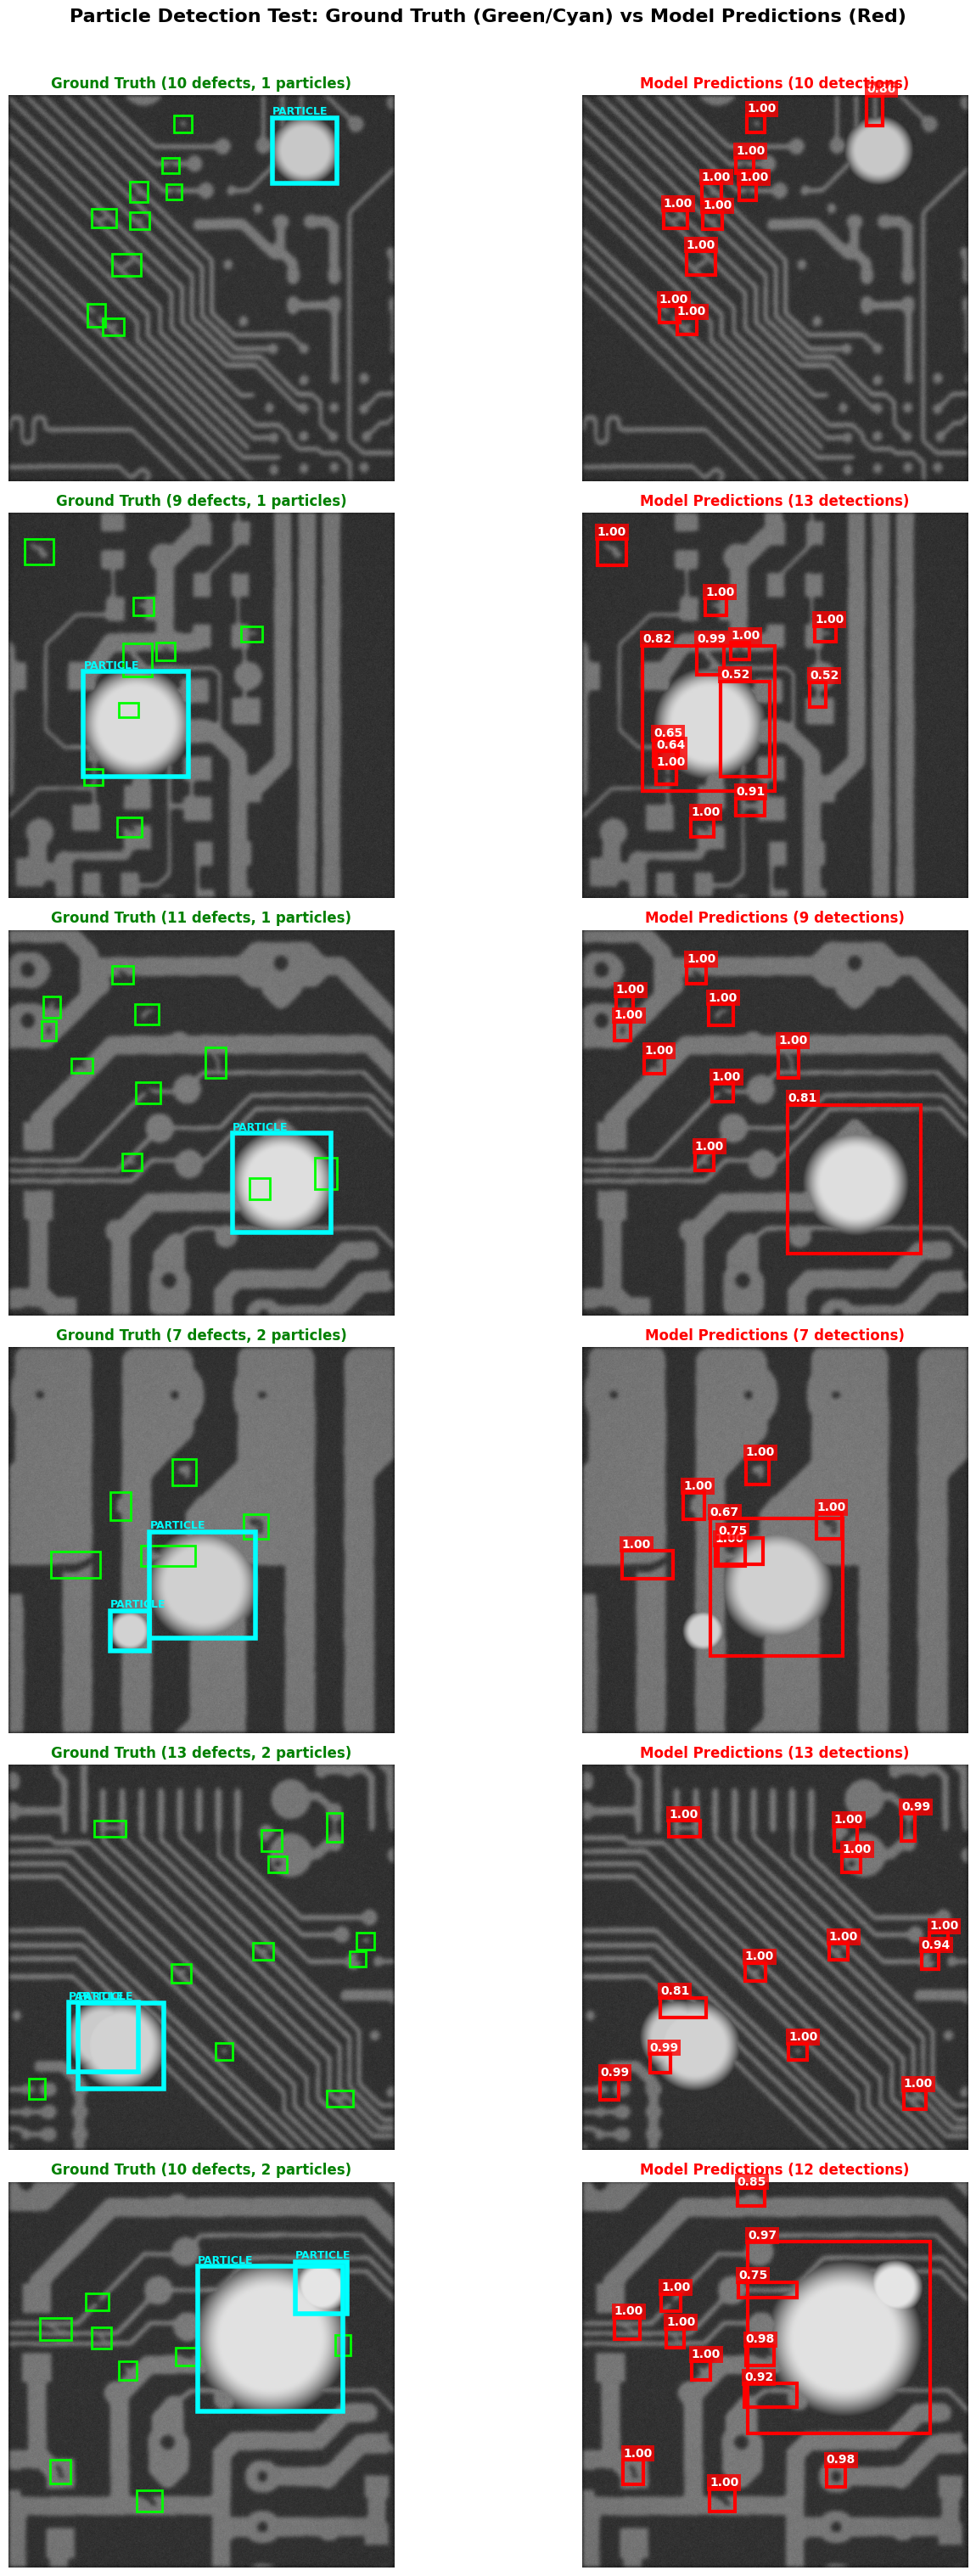


LEGEND:
  Green boxes = Original PCB defects
  Cyan boxes  = Injected bright particles (synthetic)
  Red boxes   = Model predictions with confidence scores


In [6]:
# Visualize results: Ground Truth vs Predictions

fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(16, 5 * NUM_SAMPLES))

for i, result in enumerate(results):
    img = result["augmented_img"]
    gt_boxes = result["gt_boxes"]
    particle_boxes = result["particle_boxes"]
    pred_boxes = result["pred_boxes"]
    pred_scores = result["pred_scores"]
    
    # Left: Ground Truth
    ax_gt = axes[i, 0]
    ax_gt.imshow(img)
    ax_gt.set_title(f"Ground Truth ({len(gt_boxes)} defects, {len(particle_boxes)} particles)", 
                    fontsize=12, fontweight="bold", color="green")
    ax_gt.axis("off")
    
    # Draw all GT boxes in green, highlight particles in cyan
    particle_set = set([tuple(b) for b in particle_boxes])
    for box in gt_boxes:
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        is_particle = tuple([int(x1), int(y1), int(x2), int(y2)]) in particle_set
        color = "cyan" if is_particle else "lime"
        linewidth = 4 if is_particle else 2
        rect = patches.Rectangle((x1, y1), w, h, linewidth=linewidth, edgecolor=color, facecolor="none")
        ax_gt.add_patch(rect)
        if is_particle:
            ax_gt.text(x1, y1 - 5, "PARTICLE", fontsize=9, color="cyan", fontweight="bold")
    
    # Right: Model Predictions
    ax_pred = axes[i, 1]
    ax_pred.imshow(img)
    ax_pred.set_title(f"Model Predictions ({len(pred_boxes)} detections)", 
                      fontsize=12, fontweight="bold", color="red")
    ax_pred.axis("off")
    
    # Draw predictions in red
    for box, score in zip(pred_boxes, pred_scores):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=3, edgecolor="red", facecolor="none")
        ax_pred.add_patch(rect)
        ax_pred.text(x1, y1 - 5, f"{score:.2f}", 
                     bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=2),
                     fontsize=10, color="white", fontweight="bold")

plt.suptitle("Particle Detection Test: Ground Truth (Green/Cyan) vs Model Predictions (Red)", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("LEGEND:")
print("  Green boxes = Original PCB defects")
print("  Cyan boxes  = Injected bright particles (synthetic)")
print("  Red boxes   = Model predictions with confidence scores")
print("="*80)

In [7]:
# Summary statistics

total_particles = sum(len(r["particle_boxes"]) for r in results)
total_gt = sum(len(r["gt_boxes"]) for r in results)
total_pred = sum(len(r["pred_boxes"]) for r in results)

# Check if particles were detected (simple overlap check)
particles_detected = 0
for result in results:
    for p_box in result["particle_boxes"]:
        px1, py1, px2, py2 = p_box
        p_cx, p_cy = (px1 + px2) / 2, (py1 + py2) / 2
        
        for pred_box in result["pred_boxes"]:
            x1, y1, x2, y2 = pred_box
            if x1 <= p_cx <= x2 and y1 <= p_cy <= y2:
                particles_detected += 1
                break

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nTotal samples tested: {NUM_SAMPLES}")
print(f"Total ground truth defects: {total_gt}")
print(f"  - Synthetic particles: {total_particles}")
print(f"  - Original PCB defects: {total_gt - total_particles}")
print(f"\nTotal model predictions: {total_pred}")
print(f"\nParticle detection rate: {particles_detected}/{total_particles} ({100*particles_detected/max(1,total_particles):.1f}%)")
print("="*80)


SUMMARY

Total samples tested: 6
Total ground truth defects: 60
  - Synthetic particles: 9
  - Original PCB defects: 51

Total model predictions: 64

Particle detection rate: 5/9 (55.6%)
